In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

orders = pd.read_csv('../data/orders.csv', header=None)
payments = pd.read_csv('../data/payments.csv', header=None)
customers = pd.read_csv('../data/customers.csv', header=None)
products = pd.read_csv('../data/products.csv', header=None)
order_items = pd.read_csv('../data/order_items.csv', header=None)

In [33]:
orders.columns = [
    'order_id',
    'customer_id',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

payments.columns = [
    'order_id',
    'payment_sequential',
    'payment_type',
    'payment_installments',
    'payment_value'
]

customers.columns = [
    'customer_id',
    'customer_unique_id',
    'customer_zip_code_prefix',
    'customer_city',
    'customer_state'
]

order_items.columns = [
    'order_id',
    'order_item_id',
    'product_id',
    'seller_id',
    'shipping_limit_date',
    'price',
    'freight_value'
]

In [34]:
print(products.shape)

(32951, 9)


In [35]:
products.columns = [
    'product_id',
    'product_category_name',
    'product_name_length',
    'product_description_length',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

In [37]:
print("Orders")
print(orders.head())

print("\nPayments")
print(payments.head())

print("\nCustomers")
print(customers.head())

print("\nProducts")
print(products.head())

print("\nOrder Items")
print(order_items.head())

Orders
                           order_id                       customer_id order_status     order_purchase_timestamp            order_approved_at order_delivered_carrier_date order_delivered_customer_date order_estimated_delivery_date
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d    delivered  2017-10-02 10:56:33.0000000  2017-10-02 11:07:15.0000000  2017-10-04 19:55:00.0000000   2017-10-10 21:25:13.0000000   2017-10-18 00:00:00.0000000
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef    delivered  2018-07-24 20:41:37.0000000  2018-07-26 03:24:27.0000000  2018-07-26 14:31:00.0000000   2018-08-07 15:27:45.0000000   2018-08-13 00:00:00.0000000
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089    delivered  2018-08-08 08:38:49.0000000  2018-08-08 08:55:23.0000000  2018-08-08 13:50:00.0000000   2018-08-17 18:06:29.0000000   2018-09-04 00:00:00.0000000
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82    

In [38]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

In [39]:
print("Orders:", orders.shape)
print("Payments:", payments.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Order Items:", order_items.shape)

Orders: (99441, 8)
Payments: (103886, 5)
Customers: (99441, 5)
Products: (32951, 9)
Order Items: (112650, 7)


# Brazilian E-Commerce EDA Project

## Objective
Analyze customer behavior, payment trends, delivery performance, and revenue insights using Brazilian e-commerce datasets.

In [40]:
print("Missing Values\n")

print("Orders")
print(orders.isnull().sum())

print("\nPayments")
print(payments.isnull().sum())

print("\nCustomers")
print(customers.isnull().sum())

print("\nProducts")
print(products.isnull().sum())

print("\nOrder Items")
print(order_items.isnull().sum())

Missing Values

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_length           610
product_description_length    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Ord

In [41]:
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


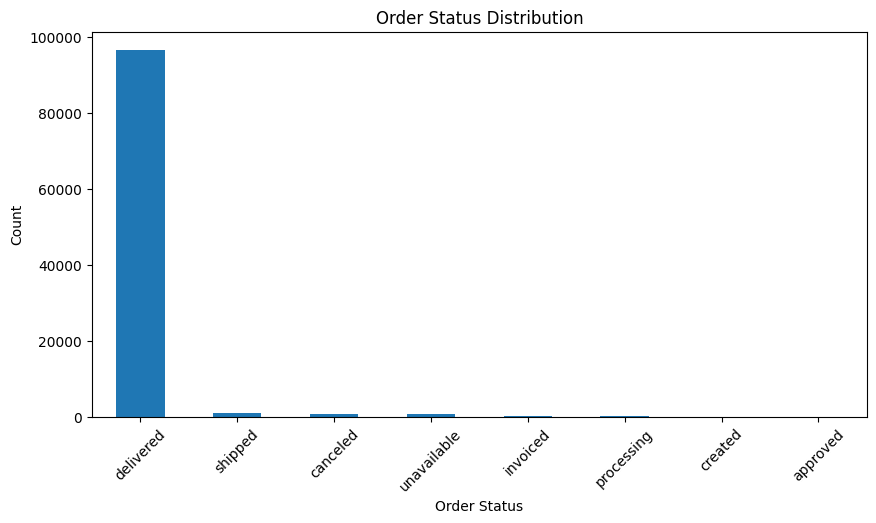

In [42]:
orders['order_status'].value_counts().plot(
    kind='bar',
    figsize=(10,5),
    title='Order Status Distribution'
)

plt.xlabel("Order Status")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.savefig(
    '../screenshots/top_states_by_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [43]:
payments['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [44]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [45]:
orders['delivery_time'] = (
    pd.to_datetime(orders['order_delivered_customer_date']) -
    pd.to_datetime(orders['order_purchase_timestamp'])
).dt.days

In [46]:
print(orders['delivery_time'].describe())

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time, dtype: float64


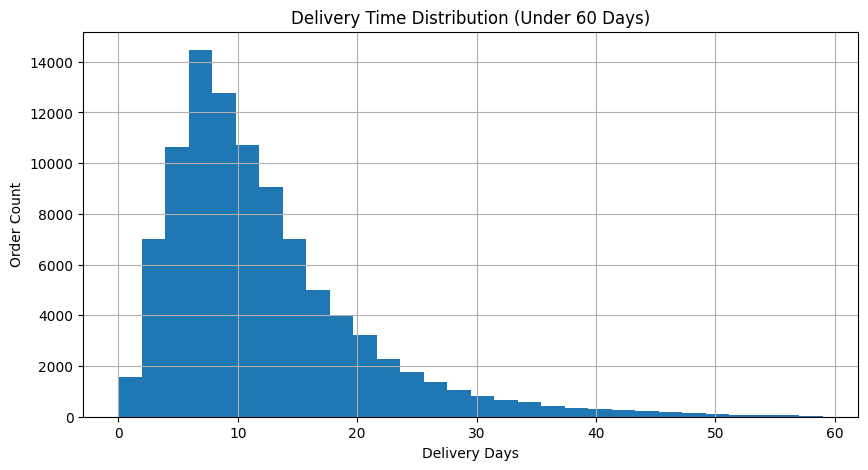

In [47]:
orders[orders['delivery_time'] < 60]['delivery_time'].hist(
    bins=30,
    figsize=(10,5)
)

plt.title('Delivery Time Distribution (Under 60 Days)')
plt.xlabel('Delivery Days')
plt.ylabel('Order Count')

plt.savefig(
    '../screenshots/top_states_by_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Delivery Time Feature Engineering

Calculated delivery duration using purchase timestamp and customer delivery timestamp.

Validated:
- Missing delivery values
- Negative delivery durations
- Outlier behavior

Removed invalid negative delivery records to improve analysis quality.

In [48]:
orders['delivery_time'].isnull().sum()

np.int64(2965)

In [49]:
orders[orders['delivery_time'] < 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time


In [50]:
orders = orders[orders['delivery_time'] >= 0]

# Revenue Analysis

Analyzing payment behavior and revenue distribution to understand customer purchasing patterns and transaction characteristics.

In [51]:
payments['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

## Payment Value Outlier Handling

Initial payment value distribution was heavily skewed by extreme high-value transactions.

Percentile analysis showed that 99% of transactions were below approximately 1040, while maximum transaction values exceeded 13,000.

To improve visualization clarity and better represent typical customer purchasing behavior, transactions above 1000 were excluded from the histogram visualization.

In [52]:
payments['payment_value'].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
90%         297.270000
95%         437.635000
99%        1039.916500
max       13664.080000
Name: payment_value, dtype: float64

# Customer Geography Analysis

Analyzing customer distribution across states and cities to identify regional demand concentration.

In [53]:
customers['customer_state'].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

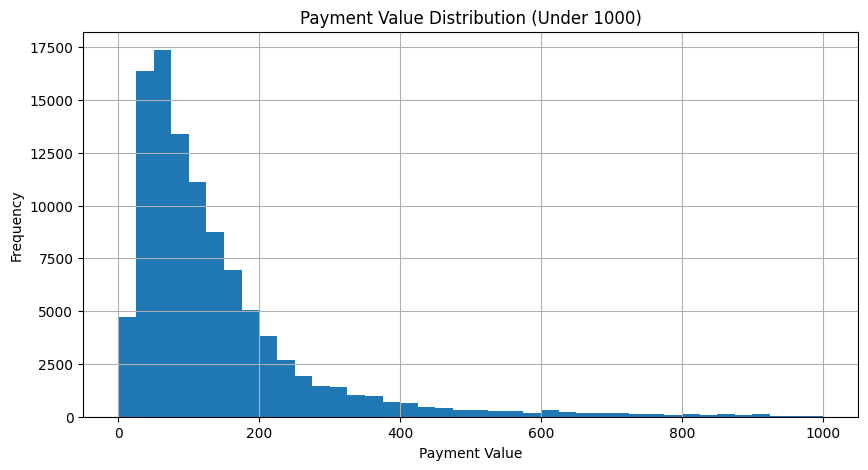

In [54]:
# Payment Value Distribution

payments[payments['payment_value'] < 1000]['payment_value'].hist(
    bins=40,
    figsize=(10,5)
)

plt.title('Payment Value Distribution (Under 1000)')
plt.xlabel('Payment Value')
plt.ylabel('Frequency')

plt.savefig(
    '../screenshots/payment_value_distribution.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

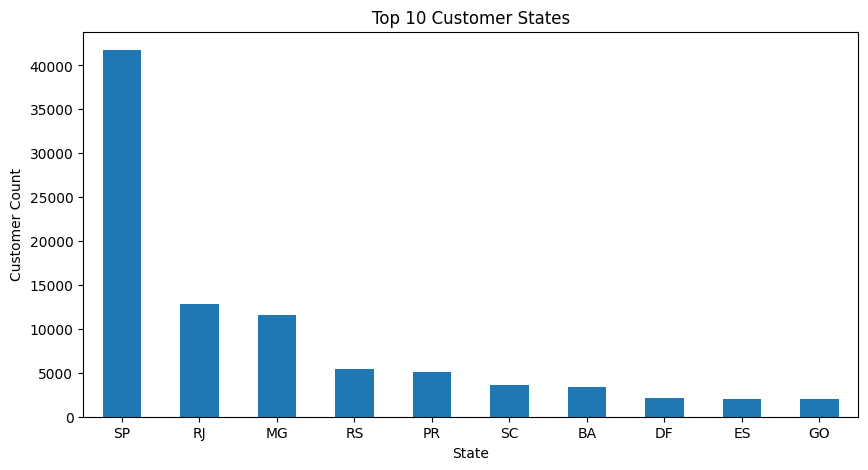

In [55]:
customers['customer_state'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Customer States')
plt.xlabel('State')
plt.ylabel('Customer Count')
plt.xticks(rotation=0)

plt.savefig(
    '../screenshots/top_states_by_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Regional Customer Concentration Insight

Customer distribution was heavily concentrated in São Paulo (SP), significantly exceeding all other regions.

This suggests:
- Strong market penetration in major urban centers
- Potential operational dependency on high-density regions
- Opportunities for regional expansion into underrepresented states

# Revenue by State Analysis

Combining customer, order, and payment data to analyze regional revenue contribution.

In [56]:
merged_df = orders.merge(
    customers,
    on='customer_id',
    how='inner'
)

merged_df = merged_df.merge(
    payments,
    on='order_id',
    how='inner'
)

print(merged_df.shape)

(100754, 17)


In [57]:
state_revenue = merged_df.groupby('customer_state')['payment_value'].sum()

state_revenue.sort_values(ascending=False).head(10)

customer_state
SP    5769221.49
RJ    2056101.21
MG    1819321.70
RS     861608.40
PR     781919.55
SC     595361.91
BA     591270.60
DF     346146.17
GO     334294.22
ES     317682.65
Name: payment_value, dtype: float64

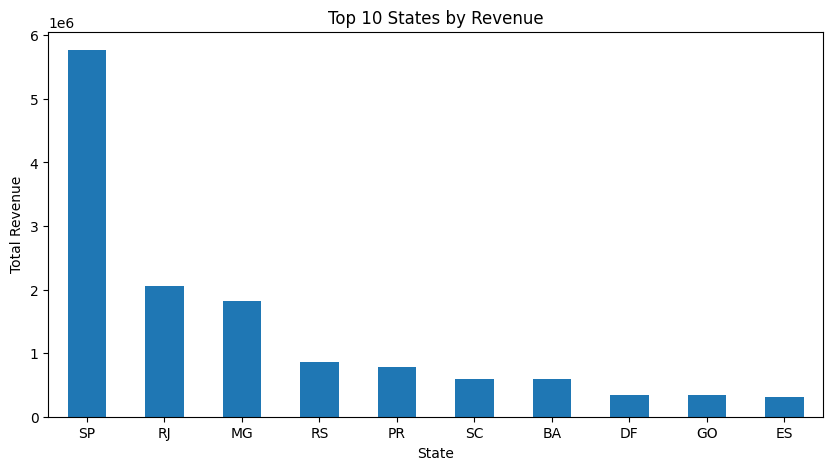

In [58]:
state_revenue.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Total Revenue')

plt.xticks(rotation=0)

plt.savefig(
    '../screenshots/top_states_by_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Revenue Concentration Insight

São Paulo (SP) generated significantly higher revenue than all other states, aligning with its dominant customer concentration.

Key observations:
- Revenue generation is heavily concentrated in a small number of states
- SP represents the strongest commercial market within the dataset
- Regional revenue imbalance may indicate opportunities for geographic expansion and targeted marketing strategies

# Final Business Insights

## Key Findings

- Customer activity and revenue were heavily concentrated in São Paulo (SP)
- Credit cards were the dominant payment method across transactions
- Most deliveries were completed within two weeks
- Payment distributions and delivery times contained significant outliers
- Data validation identified missing delivery information and invalid delivery durations
- Revenue generation was unevenly distributed across regions

## Business Implications

- High regional dependency may create operational concentration risk
- Delivery outliers may indicate logistics inefficiencies
- Strong credit card usage suggests high digital payment adoption
- Underrepresented states may present future growth opportunities

## Analytical Techniques Used

- Data cleaning
- Missing value analysis
- Feature engineering
- Outlier detection
- Distribution analysis
- Data aggregation
- Multi-table merging
- Exploratory data visualization